Import libraries

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


Load data from SQLite

In [2]:
conn = sqlite3.connect("../database/medsupply.db")

query = "SELECT * FROM sales"
df = pd.read_sql(query, conn)

conn.close()

df.head()


,date,Year,Month,Weekday Name,product,units_sold
0,2014-01-03 00:00:00,2014,1,Friday,M01AB,8.00
1,2014-01-04 00:00:00,2014,1,Saturday,M01AB,2.00
2,2014-01-05 00:00:00,2014,1,Sunday,M01AB,4.00
3,2014-01-06 00:00:00,2014,1,Monday,M01AB,5.00
4,2014-01-08 00:00:00,2014,1,Wednesday,M01AB,5.33


Basic inspection

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (14455, 6)

Columns:
Index(['date', 'Year', 'Month', 'Weekday Name', 'product', 'units_sold'], dtype='object')

Data Types:
date             object
Year              int64
Month             int64
Weekday Name     object
product          object
units_sold      float64
dtype: object

Missing Values:
date            0
Year            0
Month           0
Weekday Name    0
product         0
units_sold      0
dtype: int64


Covert date column

In [4]:
df["date"] = pd.to_datetime(df["date"])

In [5]:
print(df.dtypes)

date            datetime64[ns]
Year                     int64
Month                    int64
Weekday Name            object
product                 object
units_sold             float64
dtype: object


overall demand trend

In [6]:
daily = df.groupby("date")["units_sold"].sum().reset_index()
print(daily.head())

        date  units_sold
0 2014-01-02       48.47
1 2014-01-03      107.00
2 2014-01-04       91.35
3 2014-01-05       66.10
4 2014-01-06       58.20


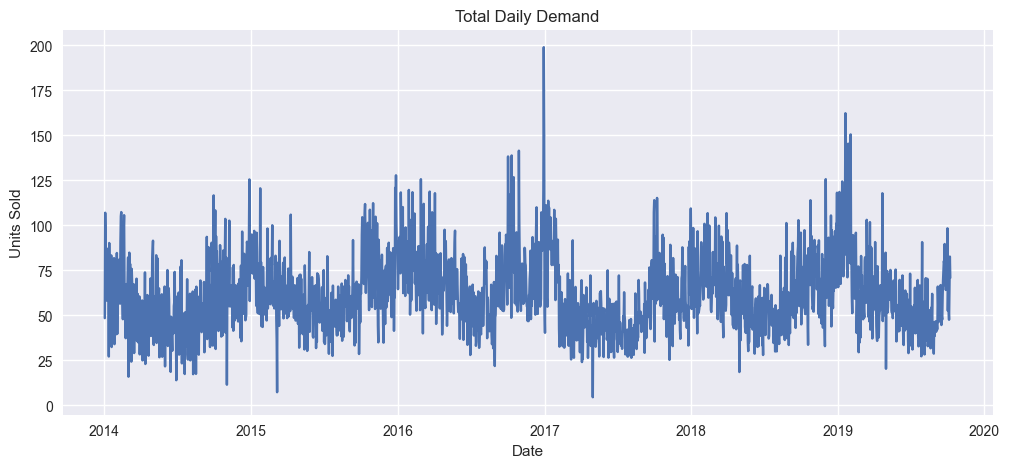

In [7]:
plt.figure(figsize=(12,5))
plt.plot(daily["date"], daily["units_sold"])         #, marker="o", linestyle= "None")
plt.title("Total Daily Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

Demand per product

In [8]:
product_totals = df.groupby("product")["units_sold"].sum().sort_values(ascending=False)
print(product_totals.head())

product
N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
Name: units_sold, dtype: float64


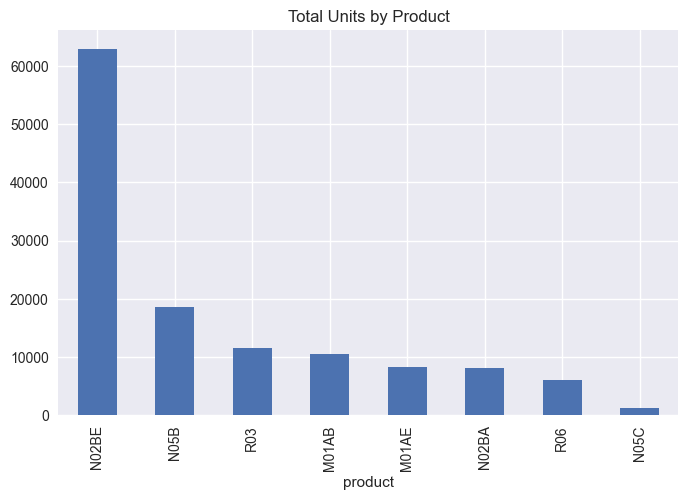

In [9]:
plt.figure(figsize=(8,5))
product_totals.plot(kind="bar")
plt.title("Total Units by Product")
plt.show()

Monthly seasonality

In [10]:
df["year_month"] = df["date"].dt.to_period("M")

monthly = df.groupby("year_month")["units_sold"].sum().reset_index()
print(monthly.head())


  year_month  units_sold
0    2014-01    1801.110
1    2014-02    1974.470
2    2014-03    1606.720
3    2014-04    1423.925
4    2014-05    1506.303


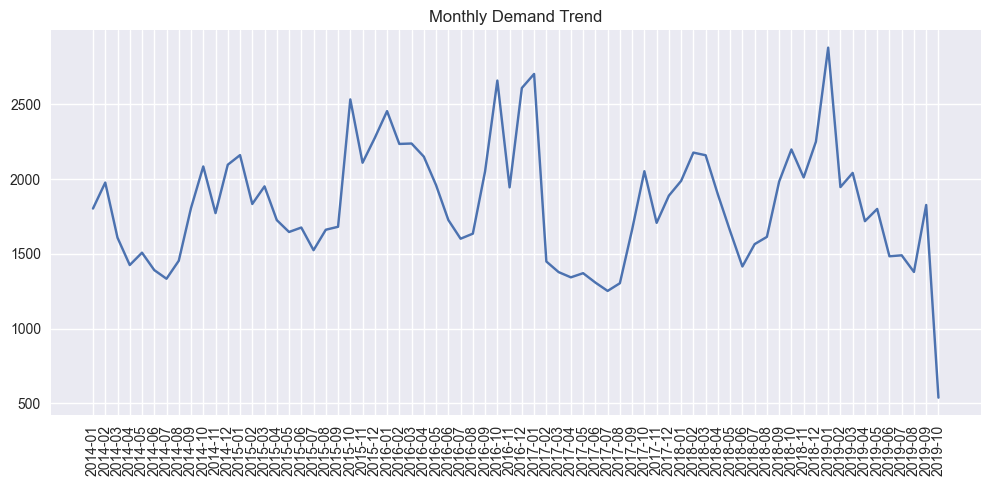

In [11]:
plt.figure(figsize=(12,5))
plt.plot(monthly["year_month"].astype(str), monthly["units_sold"])
plt.xticks(rotation=90)
plt.title("Monthly Demand Trend")
plt.show()

Weekday pattern

In [12]:
weekday = df.groupby("Weekday Name")["units_sold"].mean()
print(weekday.head())

weekday = weekday.reindex([
    "Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"
])
print(weekday.head())

Weekday Name
Friday      8.656082
Monday      8.817214
Saturday    9.508222
Sunday      9.209929
Thursday    8.466497
Name: units_sold, dtype: float64
Weekday Name
Monday       8.817214
Tuesday      8.614805
Wednesday    8.527604
Thursday     8.466497
Friday       8.656082
Name: units_sold, dtype: float64


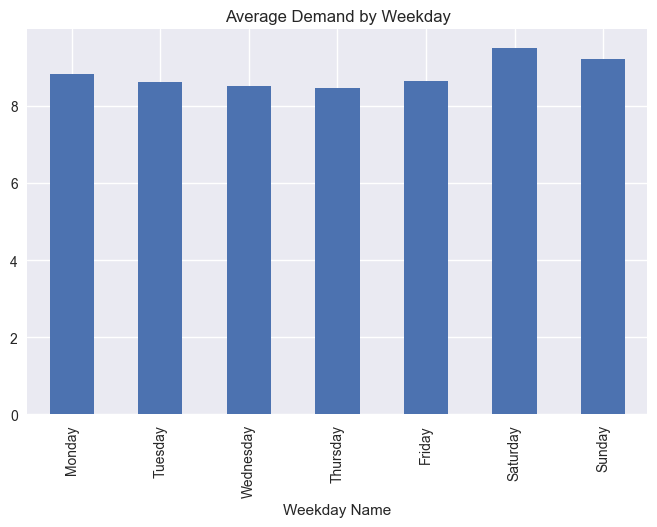

In [13]:
plt.figure(figsize=(8,5))
weekday.plot(kind="bar")
plt.title("Average Demand by Weekday")
plt.show()


Product trend comparison

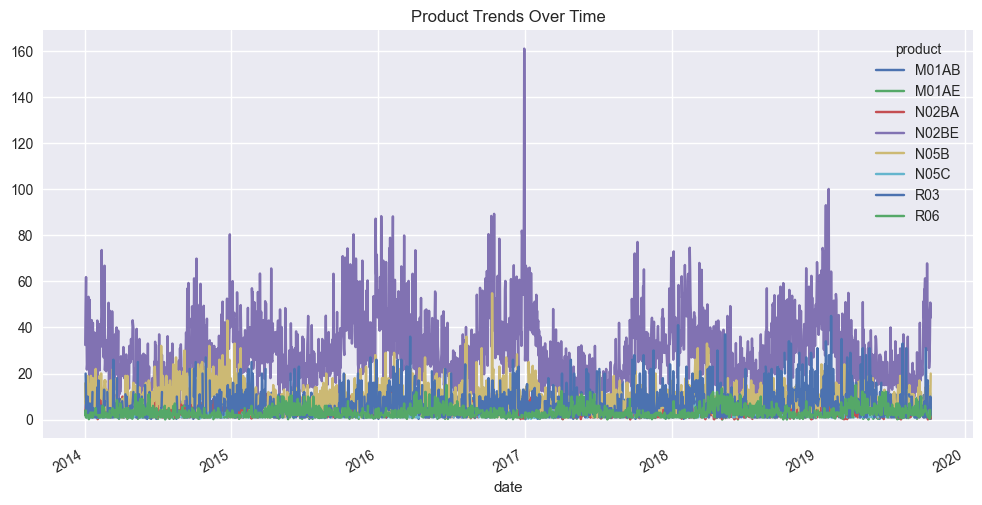

In [14]:
pivot = df.pivot_table(index="date", columns="product", values="units_sold", aggfunc="sum")

pivot.plot(figsize=(12,6))
plt.title("Product Trends Over Time")
plt.show()

Correlation heatmap

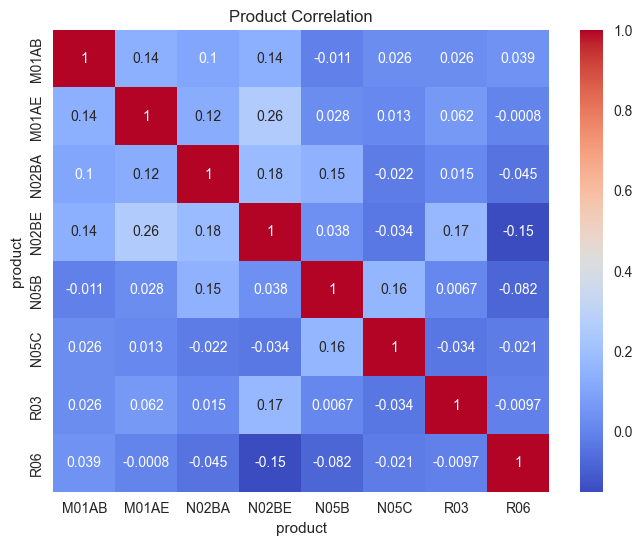

In [15]:
corr = pivot.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Product Correlation")
plt.show()


Outlier detection

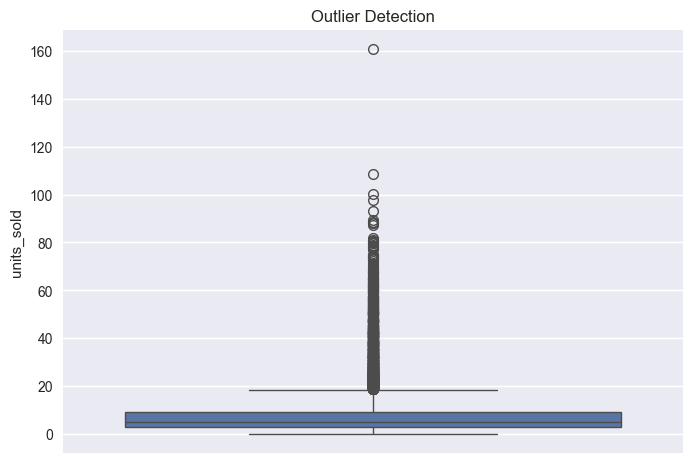

In [16]:
sns.boxplot(y=df["units_sold"])
plt.title("Outlier Detection")
plt.show()

In [17]:
df.head()

,date,Year,Month,Weekday Name,product,units_sold,year_month
0,2014-01-03,2014,1,Friday,M01AB,8.00,2014-01
1,2014-01-04,2014,1,Saturday,M01AB,2.00,2014-01
2,2014-01-05,2014,1,Sunday,M01AB,4.00,2014-01
3,2014-01-06,2014,1,Monday,M01AB,5.00,2014-01
4,2014-01-08,2014,1,Wednesday,M01AB,5.33,2014-01


Feature Engineering + ML model 

fe.1 Prepare data for ML

In [18]:
# Sort data
df = df.sort_values(["product", "date"])

# ---------- BASIC LAGS ----------
df["lag_1"] = df.groupby("product")["units_sold"].shift(1)
df["lag_2"] = df.groupby("product")["units_sold"].shift(2)
df["lag_3"] = df.groupby("product")["units_sold"].shift(3)
df["lag_7"] = df.groupby("product")["units_sold"].shift(7)

# ---------- ROLLING FEATURES ----------
df["rolling_3"] = df.groupby("product")["units_sold"].rolling(3).mean().reset_index(0, drop=True)
df["rolling_7"] = df.groupby("product")["units_sold"].rolling(7).mean().reset_index(0, drop=True)
df["rolling_14"] = df.groupby("product")["units_sold"].rolling(14).mean().reset_index(0, drop=True)

# Rolling std (captures volatility)
df["rolling_std_7"] = df.groupby("product")["units_sold"].rolling(7).std().reset_index(0, drop=True)

# ---------- CALENDAR FEATURES ----------
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["day_of_month"] = df["date"].dt.day
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

# Weekend flag
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

# ---------- TREND FEATURES ----------
# Expanding mean (overall trend)
df["expanding_mean"] = df.groupby("product")["units_sold"].expanding().mean().reset_index(0, drop=True)
# Shift to avoid data leakage (use only past data for prediction)
df["expanding_mean"] = df.groupby("product")["expanding_mean"].shift(1)

# ---------- TARGET SHIFT ----------
# Next day demand prediction target
df["target"] = df.groupby("product")["units_sold"].shift(-1)

# ---------- DROP NA ----------
df_model = df.dropna()

df_model.head()

,date,Year,Month,Weekday Name,product,units_sold,year_month,lag_1,lag_2,lag_3,...,rolling_7,rolling_14,rolling_std_7,day_of_week,month,day_of_month,week_of_year,is_weekend,expanding_mean,target
13,2014-01-17,2014,1,Friday,M01AB,2.00,2014-01,6.00,4.00,6.0,...,4.620000,4.905000,2.060129,4,1,17,3,0,5.128462,1.00
14,2014-01-18,2014,1,Saturday,M01AB,1.00,2014-01,2.00,6.00,4.0,...,4.048571,4.405000,2.454217,5,1,18,3,1,4.905000,4.33
15,2014-01-19,2014,1,Sunday,M01AB,4.33,2014-01,1.00,2.00,6.0,...,4.381429,4.571429,2.282034,6,1,19,3,1,4.644667,6.00
16,2014-01-20,2014,1,Monday,M01AB,6.00,2014-01,4.33,1.00,2.0,...,4.190000,4.714286,2.035362,0,1,20,4,0,4.625000,2.00
17,2014-01-21,2014,1,Tuesday,M01AB,2.00,2014-01,6.00,4.33,1.0,...,3.618571,4.500000,2.003767,1,1,21,4,0,4.705882,7.00


fe.11 - (That one product alone is pulling overall MAE up.) and (The model does not properly differentiate product behavior.) 

Add Product One-Hot Encoding

In [19]:
# One-hot encode product
df_model = pd.get_dummies(df_model, columns=["product"], drop_first=False)

# Extract product columns
product_cols = [c for c in df_model.columns if c.startswith("product_")]

print("Product columns created:", product_cols)

Product columns created: ['product_M01AB', 'product_M01AE', 'product_N02BA', 'product_N02BE', 'product_N05B', 'product_N05C', 'product_R03', 'product_R06']


In [20]:
df_model.head()

,date,Year,Month,Weekday Name,units_sold,year_month,lag_1,lag_2,lag_3,lag_7,...,expanding_mean,target,product_M01AB,product_M01AE,product_N02BA,product_N02BE,product_N05B,product_N05C,product_R03,product_R06
13,2014-01-17,2014,1,Friday,2.00,2014-01,6.00,4.00,6.0,5.00,...,5.128462,1.00,True,False,False,False,False,False,False,False
14,2014-01-18,2014,1,Saturday,1.00,2014-01,2.00,6.00,4.0,5.00,...,4.905000,4.33,True,False,False,False,False,False,False,False
15,2014-01-19,2014,1,Sunday,4.33,2014-01,1.00,2.00,6.0,2.00,...,4.644667,6.00,True,False,False,False,False,False,False,False
16,2014-01-20,2014,1,Monday,6.00,2014-01,4.33,1.00,2.0,7.34,...,4.625000,2.00,True,False,False,False,False,False,False,False
17,2014-01-21,2014,1,Tuesday,2.00,2014-01,6.00,4.33,1.0,6.00,...,4.705882,7.00,True,False,False,False,False,False,False,False


fe.2 Define X and y

In [21]:
base_features = [
    "lag_1","lag_2","lag_3","lag_7",
    "rolling_3","rolling_7","rolling_14",
    "rolling_std_7",
    "day_of_week","month","day_of_month","week_of_year","is_weekend",
    "expanding_mean"
]

features = base_features + product_cols

X = df_model[features]
Y = df_model["target"]

fe.3 split data (time based)

In [22]:
split_date = df_model["date"].quantile(0.8)

train = df_model[df_model["date"] <= split_date]
test = df_model[df_model["date"] > split_date]

X_train = train[features]
y_train = train["target"]

X_test = test[features]
y_test = test["target"]

fe.4 Metrics we will use 

In [23]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def mape(y_true, y_pred, eps=1e-6):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def evaluate(y_true, y_pred, name="model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    m = mape(y_true, y_pred)
    print(f"\n{name}")
    print(f"MAE : {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R2  : {r2:.3f}")
    print(f"MAPE: {m:.2f}%")
    return {"model": name, "mae": mae, "rmse": rmse, "r2": r2, "mape": m}

fe.5 Baseline model - Linear Regression

In [24]:
from sklearn.linear_model import LinearRegression  

lr = LinearRegression()
# “Look at these features (X_train) and learn how they relate to the correct answers (y_train).”
lr.fit(X_train, y_train)
y_predlr = lr.predict(X_test)

res_lr = evaluate(y_test, y_predlr, "Linear Regression Baseline")


Linear Regression Baseline
MAE : 3.433
RMSE: 5.662
R2  : 0.759
MAPE: 83.50%


fe.6 Random FOrest 

In [25]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_predrf = rf.predict(X_test)
res_rf = evaluate(y_test, y_predrf, "Random Forest")


Random Forest
MAE : 3.459
RMSE: 5.641
R2  : 0.761
MAPE: 90.02%


fe.7 Gradient Boosting Regressor 

In [26]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

y_predgbr = gbr.predict(X_test)
res_gbr = evaluate(y_test, y_predgbr, "Gradient Boosting")


Gradient Boosting
MAE : 3.425
RMSE: 5.744
R2  : 0.752
MAPE: 85.96%


fe8. Compare results in a table

In [27]:
import pandas as pd

results = pd.DataFrame([res_lr, res_rf, res_gbr]).sort_values("mae")
results

,model,mae,rmse,r2,mape
2,Gradient Boosting,3.424519,5.743808,0.752447,85.958004
0,Linear Regression Baseline,3.433062,5.661915,0.759456,83.495306
1,Random Forest,3.458630,5.640507,0.761272,90.021027


fe8. small but important checks 

a) plot actual vs predicted (sanity)

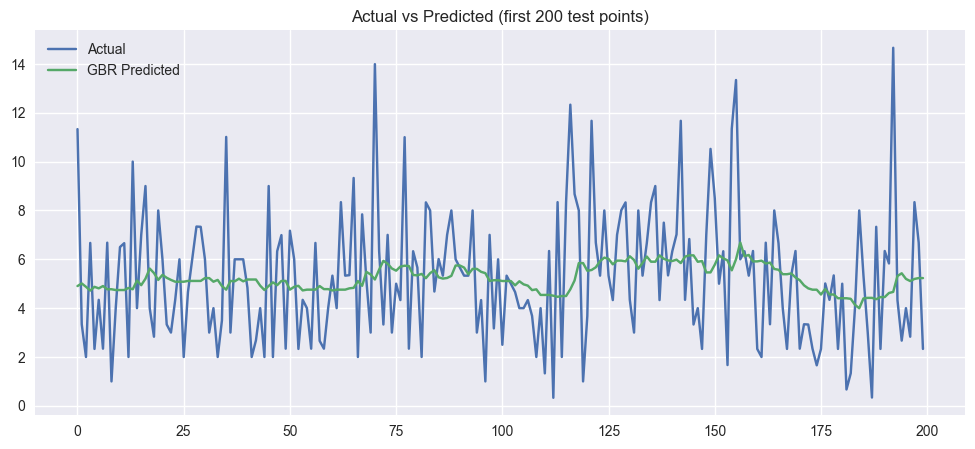

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_predgbr[:200], label="GBR Predicted")
plt.legend()
plt.title("Actual vs Predicted (first 200 test points)")
plt.show()

In [29]:
print("Average demand:", y_test.mean())

Average demand: 9.039357783212365


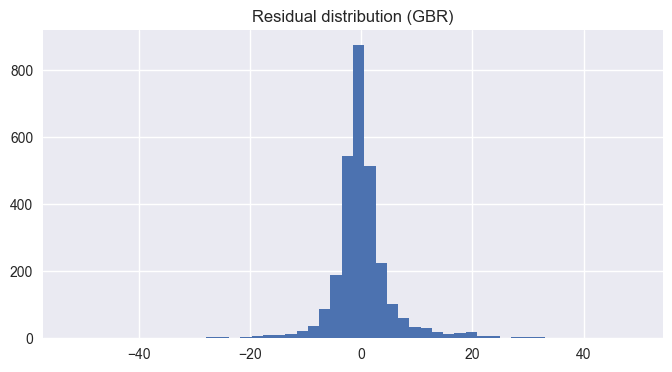

In [30]:
residuals = y_test.values - y_predgbr
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=50)
plt.title("Residual distribution (GBR)")
plt.show()

fe.9 create a proper "result summary" + MAE% (clean reporting)

In [31]:
print("Average demand:", y_test.mean())
print("GBR MAE:", res_gbr["mae"])
print("MAE as % of demand:", res_gbr["mae"] / y_test.mean())

Average demand: 9.039357783212365
GBR MAE: 3.424519231337566
MAE as % of demand: 0.378845412856374


fe.10. Per-product performance (this tells if one product is causing most error.)

In [32]:
# 1) Start from your test set
test_eval = test.copy()

# 2) Add predictions
test_eval["pred_gbr"] = y_predgbr

# 3) Absolute error
test_eval["abs_error"] = (test_eval["target"] - test_eval["pred_gbr"]).abs()

# 4) Reconstruct product label from one-hot columns
prod_cols = [c for c in test_eval.columns if c.startswith("product_")]
test_eval["product"] = (
    test_eval[prod_cols]
    .idxmax(axis=1)
    .str.replace("product_", "", regex=False)
)

# 5) Per-product performance
prod_perf = (
    test_eval.groupby("product")
    .agg(
        avg_actual=("target", "mean"),
        mae=("abs_error", "mean"),
        count=("abs_error", "count")
    )
    .sort_values("mae", ascending=False)
)

prod_perf

,avg_actual,mae,count
product,,,
N02BE,31.249323,9.115181,402
R03,9.116643,5.688704,349
N05B,8.743284,3.222292,402
M01AB,5.400274,2.156720,401
M01AE,3.916287,1.624161,400
R06,3.698556,1.605051,367
N02BA,3.223643,1.548595,387
N05C,1.832258,1.009730,155


In [33]:
print("Worst 3 products by MAE:")
display(prod_perf.head(3))

print("\nBest 3 products by MAE:")
display(prod_perf.tail(3))

Worst 3 products by MAE:


,avg_actual,mae,count
product,,,
N02BE,31.249323,9.115181,402
R03,9.116643,5.688704,349
N05B,8.743284,3.222292,402



Best 3 products by MAE:


,avg_actual,mae,count
product,,,
R06,3.698556,1.605051,367
N02BA,3.223643,1.548595,387
N05C,1.832258,1.009730,155


<Axes: title={'center': 'MAE by Product (GBR)'}, xlabel='product'>

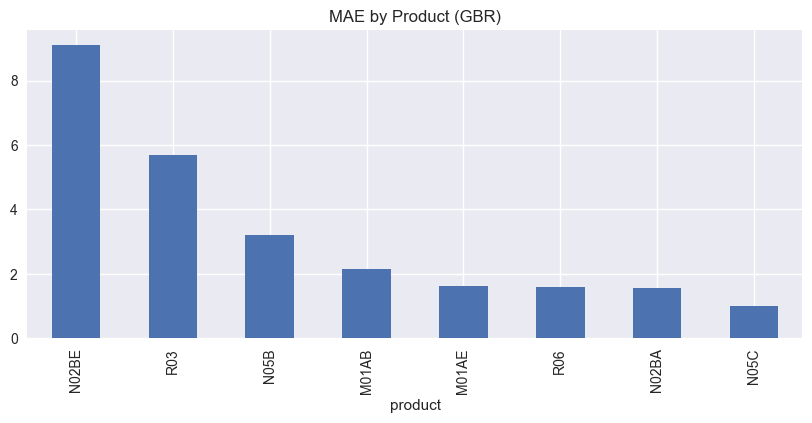

In [34]:
prod_perf["mae"].plot(kind="bar", figsize=(10,4), title="MAE by Product (GBR)")